## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load both Datasets

In [2]:
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print(fear.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
print("Fear Shape:", fear.shape)
print("Trades Shape:", trades.shape)

Fear Shape: (2644, 4)
Trades Shape: (211224, 16)


In [7]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

### Check missing values

In [9]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### Remove Duplicate Row

In [11]:
fear = fear.drop_duplicates()

trades = trades.drop_duplicates()

In [12]:
print(fear.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


### Clean column name

In [13]:
fear.columns = fear.columns.str.strip()

trades.columns = trades.columns.str.strip()

print(fear.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


### Convert date column in Fear & Greed dataset

In [14]:
fear["date"] = pd.to_datetime(fear["date"]).dt.normalize()

### Convert timestamp in Trader dataset

In [15]:
trades["date"] = pd.to_datetime(trades["Timestamp IST"],errors="coerce").dt.normalize()

In [16]:
print(fear["date"].dtype)
print(trades["date"].dtype)

datetime64[ns]
datetime64[ns]


### Merge both datasets

In [17]:
merged = trades.merge(fear[["date", "classification"]],on="date",how="left")

In [18]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [19]:
print(merged.shape)

print(merged.columns)

(211224, 18)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')


### Check sentiment distribution

In [20]:
merged["classification"].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

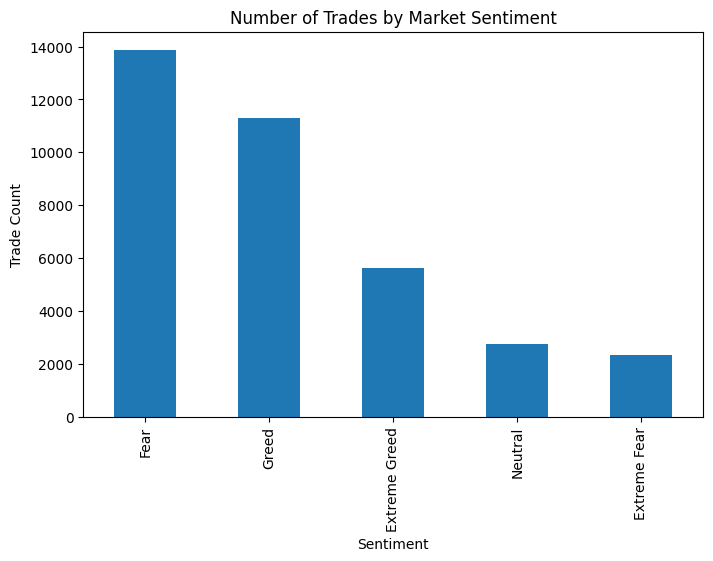

In [21]:
merged["classification"].value_counts().plot(kind="bar",figsize=(8,5))

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")

plt.show()

### Average Profit/Loss by Sentiment

In [24]:
merged.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64

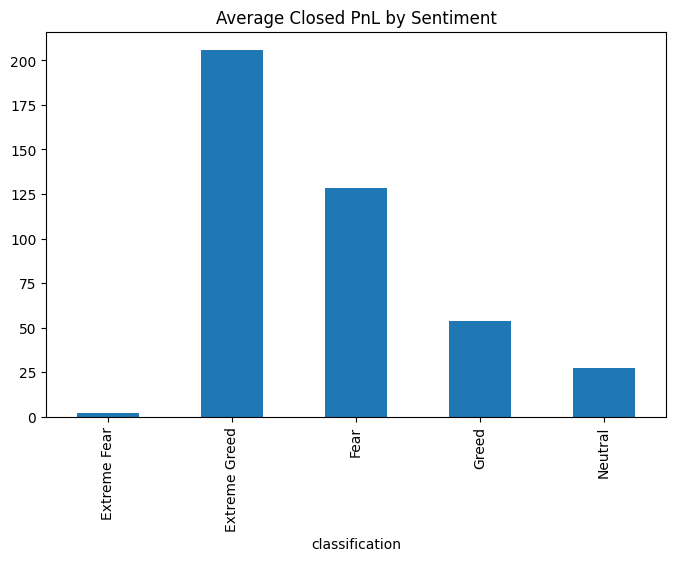

In [25]:
merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar",figsize=(8,5))

plt.title("Average Closed PnL by Sentiment")

plt.show()

### Total Profit by Sentiment

In [26]:
merged.groupby("classification")["Closed PnL"].sum()

classification
Extreme Fear     4.399937e+03
Extreme Greed    1.156894e+06
Fear             1.779226e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Name: Closed PnL, dtype: float64

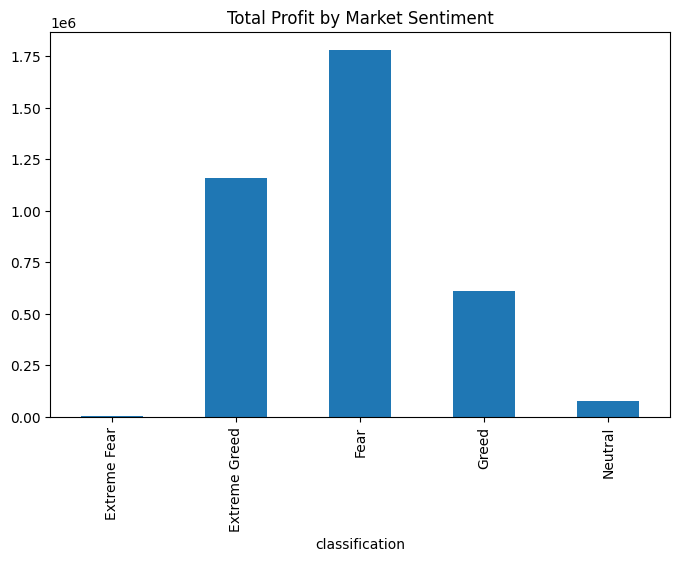

In [27]:
merged.groupby("classification")["Closed PnL"].sum().plot(kind="bar",figsize=(8,5))

plt.title("Total Profit by Market Sentiment")

plt.show()

### Compare Buy vs Sell Performance

In [29]:
merged.groupby(["classification","Side"])["Closed PnL"].mean()

classification  Side
Extreme Fear    BUY      -3.248825
                SELL      7.076480
Extreme Greed   BUY       9.047055
                SELL    288.350131
Fear            BUY     210.426466
                SELL     36.824047
Greed           BUY      15.661324
                SELL     89.201657
Neutral         BUY      12.484274
                SELL     35.669805
Name: Closed PnL, dtype: float64

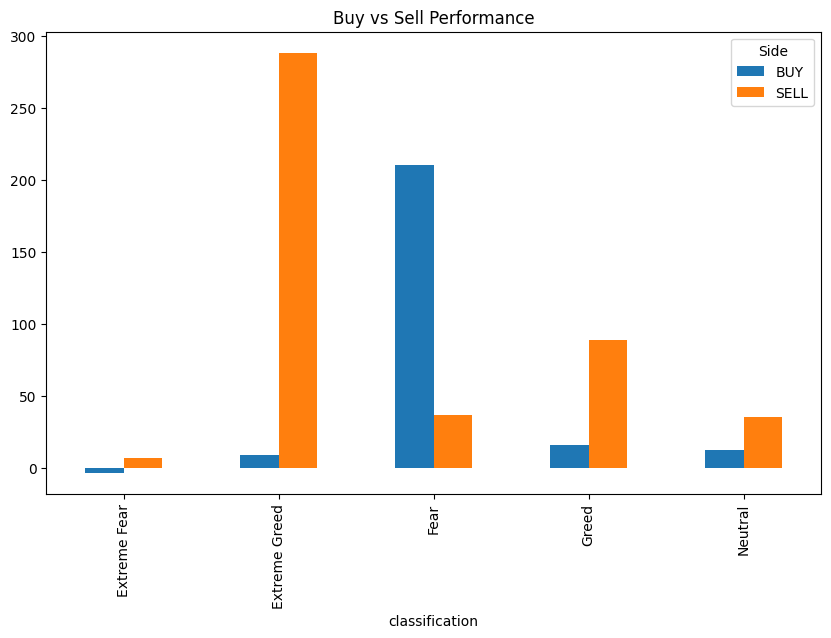

In [30]:
buy_sell = merged.groupby(["classification","Side"])["Closed PnL"].mean().unstack()

buy_sell.plot(kind="bar",figsize=(10,6))

plt.title("Buy vs Sell Performance")

plt.show()

### Average Trade Size by Sentiment

In [33]:
merged.groupby("classification")["Size USD"].mean()

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Size USD, dtype: float64

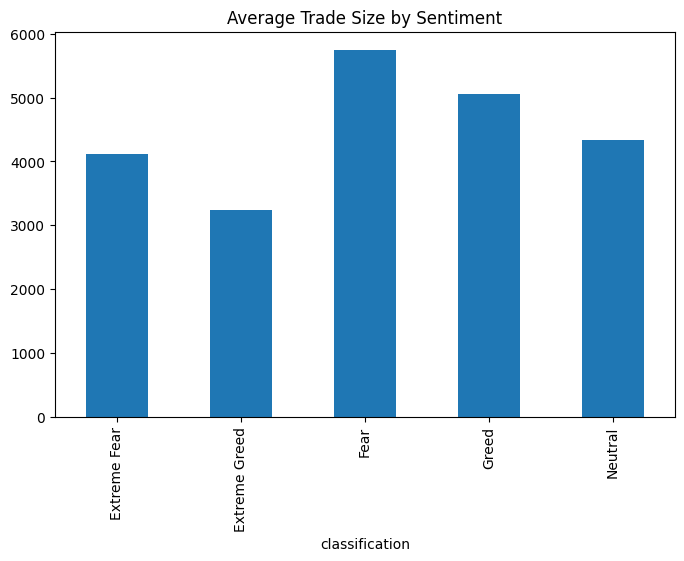

In [34]:
merged.groupby("classification")["Size USD"].mean().plot(kind="bar",figsize=(8,5))

plt.title("Average Trade Size by Sentiment")

plt.show()

### Coin-wise Profit Analysis

In [35]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

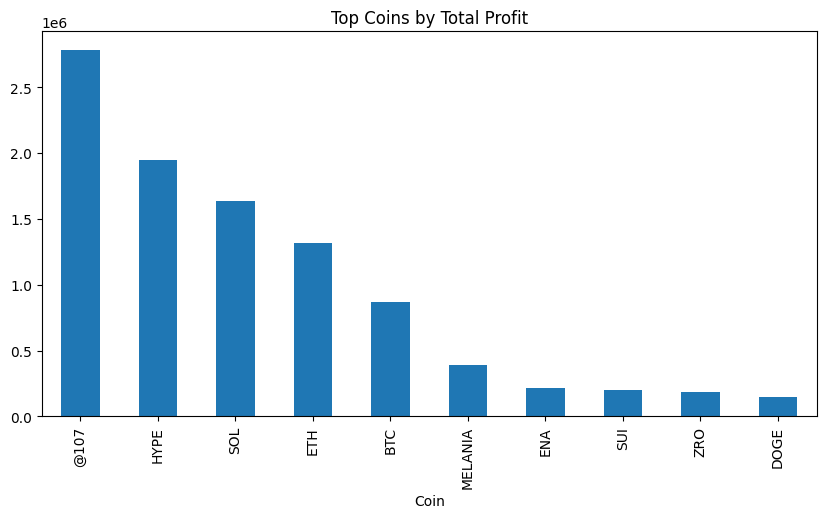

In [36]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top Coins by Total Profit")

plt.show()

### Direction Analysis

In [37]:
merged.groupby("Direction")["Closed PnL"].mean()

Direction
Auto-Deleveraging             7184.807003
Buy                              0.000000
Close Long                      74.426422
Close Short                    103.012804
Liquidated Isolated Short   -12752.913040
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053081
Settlement                     -29.215368
Short > Long                   154.190415
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64

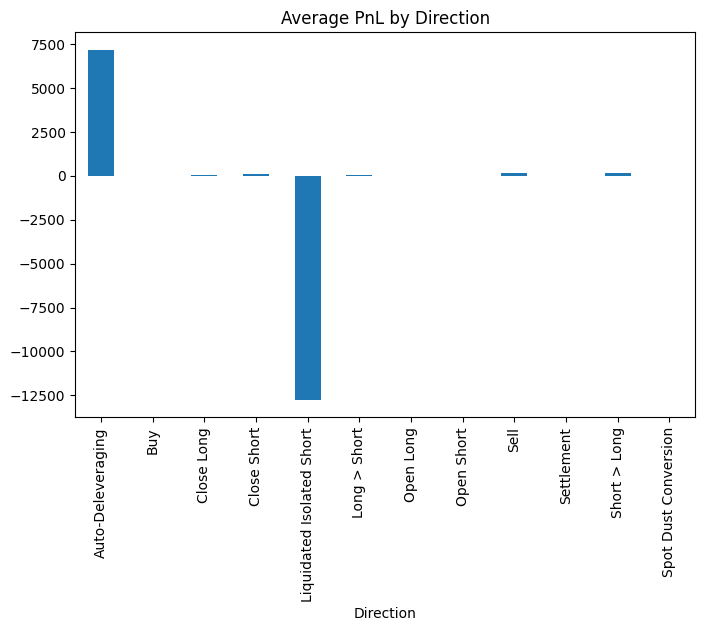

In [38]:
merged.groupby("Direction")["Closed PnL"].mean().plot(kind="bar",figsize=(8,5))

plt.title("Average PnL by Direction")

plt.show()

### Sentiment + Direction

In [39]:
merged.groupby(["classification","Direction"])["Closed PnL"].mean()

classification  Direction           
Extreme Fear    Buy                        0.000000
                Close Long                 9.841405
                Close Short              -35.934958
                Open Long                  0.000000
                Open Short                 0.000000
                Sell                      36.541817
                Short > Long              14.478305
                Spot Dust Conversion       0.000000
Extreme Greed   Buy                        0.000000
                Close Long               -80.470063
                Close Short               23.470256
                Long > Short              -0.148420
                Open Long                  0.000000
                Open Short                 0.000000
                Sell                     546.161250
                Short > Long               6.193644
                Spot Dust Conversion       0.000000
Fear            Buy                        0.000000
                Close Long 

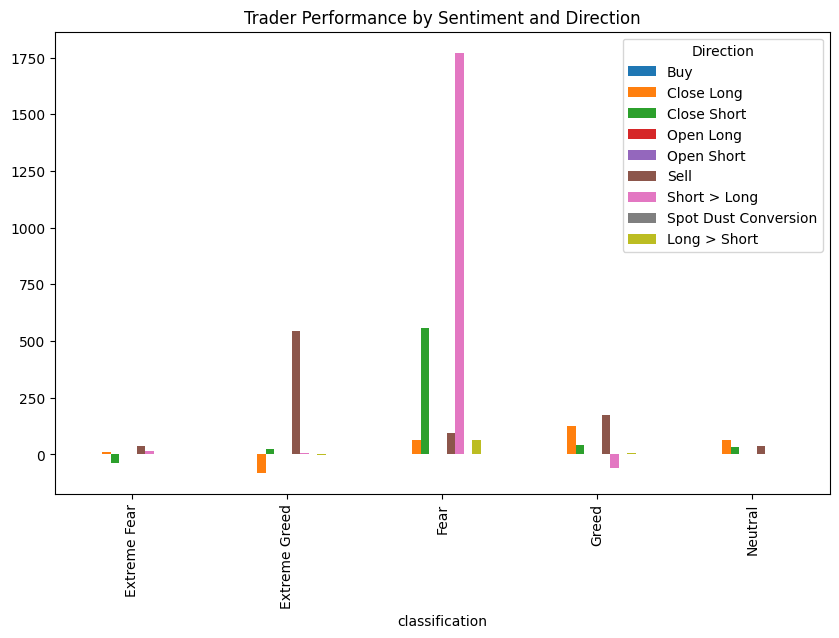

In [40]:
temp = merged.groupby(["classification","Direction"])["Closed PnL"].mean().unstack()

temp.plot(kind="bar",figsize=(10,6))

plt.title("Trader Performance by Sentiment and Direction")

plt.show()

### Fear vs Greed Overall Summary

In [41]:
summary = merged.groupby("classification").agg({"Closed PnL":"mean","Size USD":"mean","Trade ID":"count"})

summary

,Closed PnL,Size USD,Trade ID
classification,,,
Extreme Fear,1.891632,4118.761840,2326
Extreme Greed,205.816345,3242.085086,5621
Fear,128.287950,5744.782685,13869
Greed,53.988003,5051.878829,11292
Neutral,27.088803,4332.202906,2756


In [42]:
summary.columns = ["Average_PnL","Average_Trade_Size","Total_Trades"]

summary

,Average_PnL,Average_Trade_Size,Total_Trades
classification,,,
Extreme Fear,1.891632,4118.761840,2326
Extreme Greed,205.816345,3242.085086,5621
Fear,128.287950,5744.782685,13869
Greed,53.988003,5051.878829,11292
Neutral,27.088803,4332.202906,2756


### Winning Trades Percentage

In [43]:
merged["Win"] = (merged["Closed PnL"] > 0)

In [44]:
win_rate = merged.groupby("classification")["Win"].mean()*100

win_rate

classification
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: Win, dtype: float64

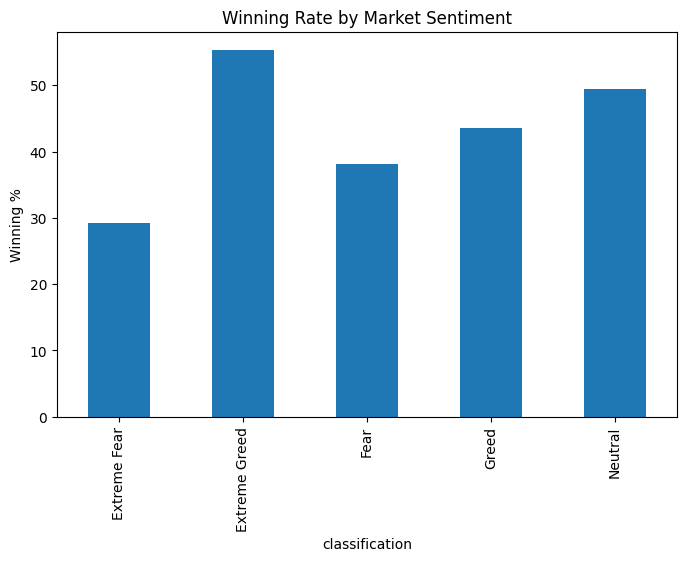

In [45]:
win_rate.plot(kind="bar",figsize=(8,5))

plt.title("Winning Rate by Market Sentiment")

plt.ylabel("Winning %")

plt.show()

### Top 10 Profitable Traders

In [46]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

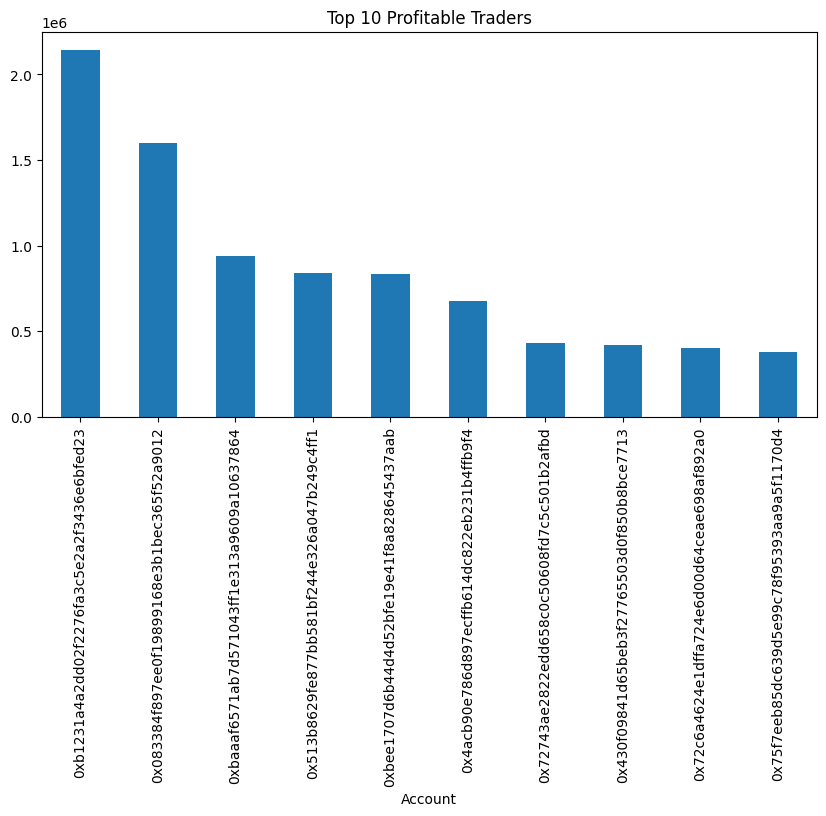

In [47]:
top_traders.plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Profitable Traders")

plt.show()

## Conclusion
This analysis explored the relationship between trader performance and Bitcoin market sentiment.

Results indicate that market sentiment influences trading outcomes, trade size, and win rate. Traders showed different behaviors during Fear and Greed periods.

These findings suggest that sentiment indicators can be used alongside traditional risk management methods to improve trading decisions.